# Praktikum W5S3: Hierarchical Clustering

Beda dari K-Means, di sini kita nggak perlu nentuin jumlah klaster dari awal. Algoritma bakal gabungin titik-titik yang paling mirip sedikit demi sedikit sampai jadi satu klaster besar, hasilnya digambar jadi dendrogram (diagram pohon).

### Percobaan 1: Dataset sederhana

Dipakai 6 titik dulu biar gampang dipahami.

In [24]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])

Menghitung jarak antar semua titik, biar tau mana yang paling deket satu sama lain.

In [25]:
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                            columns=['a', 'b', 'c', 'd', 'e', 'f'],
                            index=['a', 'b', 'c', 'd', 'e', 'f'])

print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


Titik `d` dan `e` paling deket (jarak 1.0), jadi kemungkinan bakal digabung paling awal.

Melakukan clustering dengan single linkage (jarak klaster dihitung dari titik terdekat antar klaster).

In [26]:
linked = linkage(data, method='single')

Menggambar hasilnya jadi dendrogram.

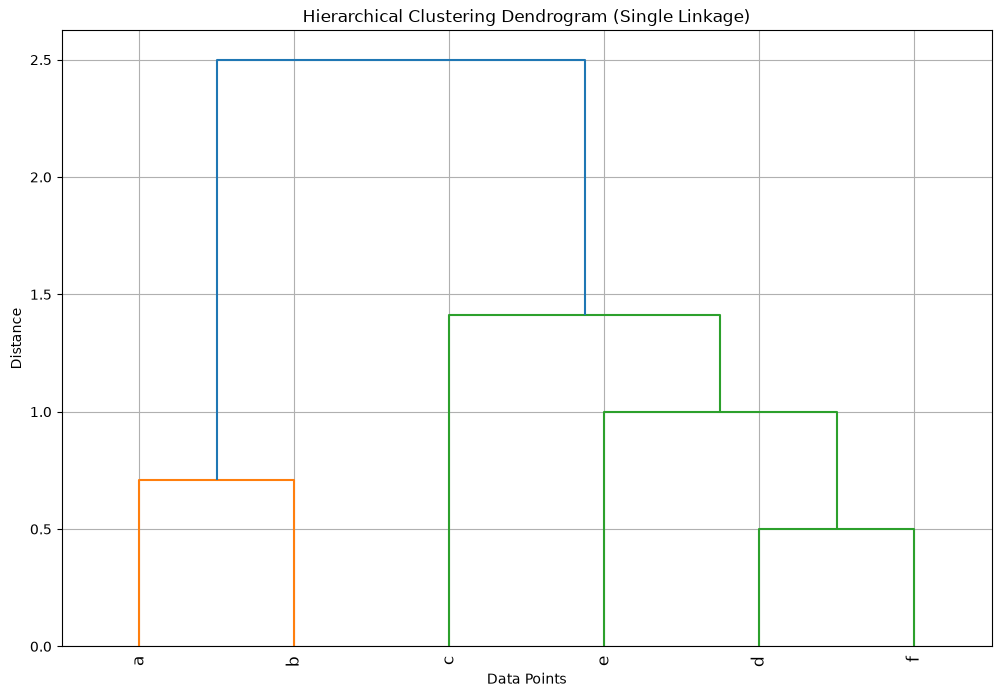

In [27]:
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Dari dendrogram kelihatan `d` dan `f` gabung duluan, disusul `a` dan `b`, lalu semuanya nyambung jadi satu di bagian atas.

### Percobaan 2: Dataset Mall Customers

Sekarang pakai data pelanggan mal, fokus ke dua fitur: income dan spending score.

In [28]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Mengambil kolom Annual Income dan Spending Score.

In [29]:
x = df.iloc[:, [3, 4]].values

Menyamakan skala dua fitur ini dengan StandardScaler, biar adil pas dihitung jaraknya.

In [30]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Melakukan clustering dengan complete linkage (jarak klaster dihitung dari titik terjauh antar klaster).

In [31]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

Menggambar dendrogramnya.

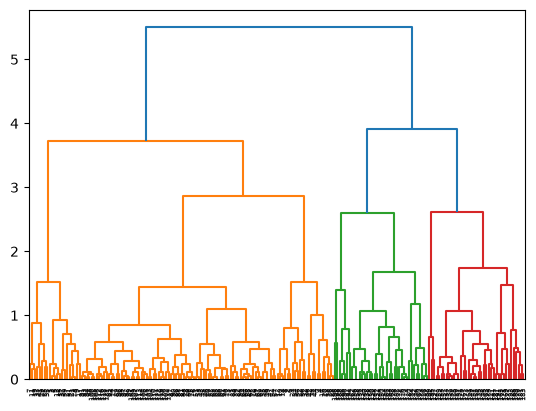

In [32]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

Hasilnya kebentuk tiga kelompok besar (oranye, hijau, merah) — bisa dibilang ini mewakili pelanggan dengan pengeluaran rendah, sedang, dan tinggi. Info ini bisa dipakai buat bikin promo yang beda-beda per kelompok.

## Tugas: Bandingkan Single, Complete, Average Linkage

Masih pakai data 6 titik tadi, dicoba tiga metode linkage sekaligus buat dibandingkan.

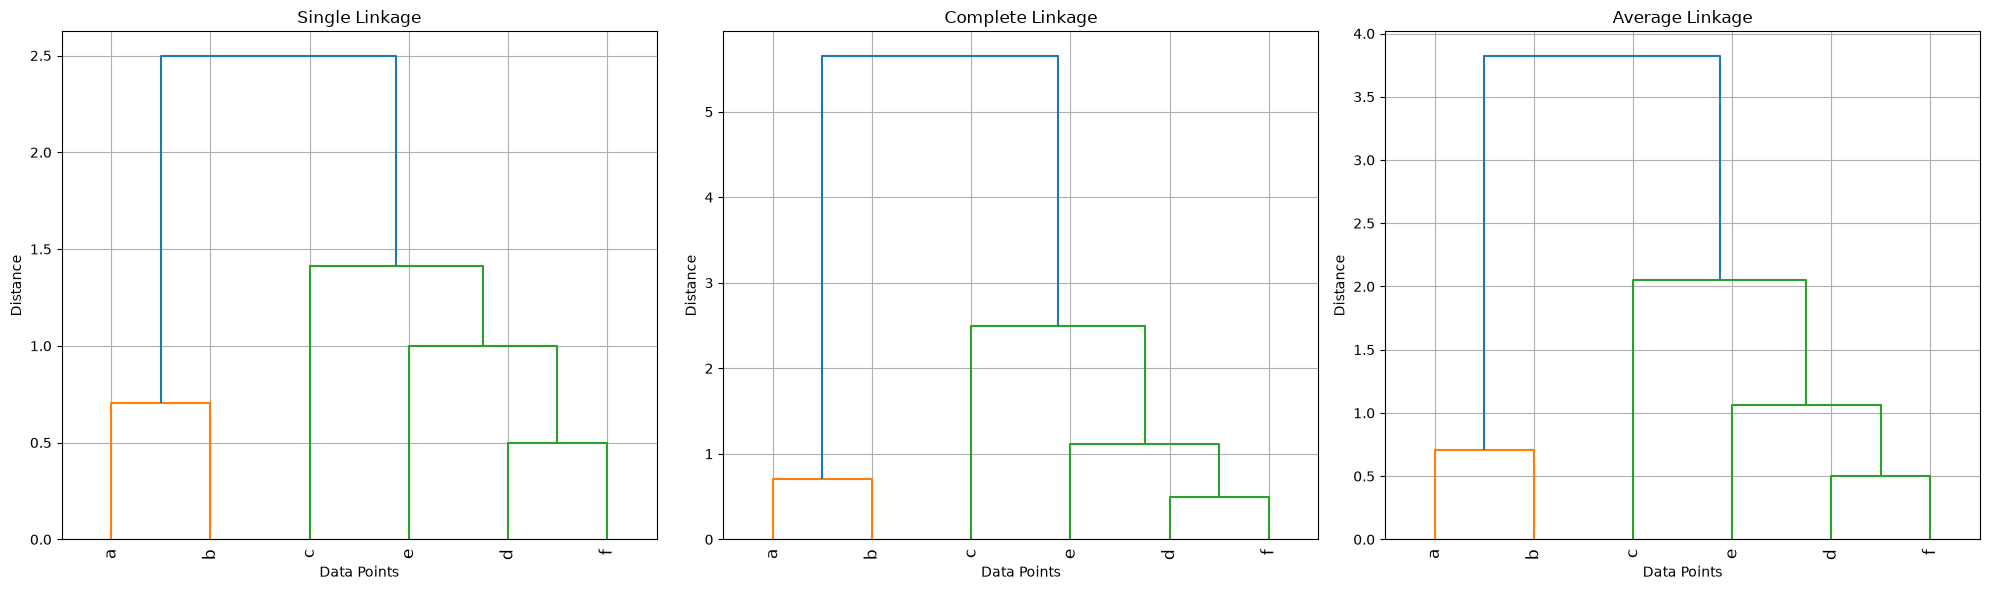

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
methods = ['single', 'complete', 'average']

for ax, method in zip(axes, methods):
    linked = linkage(data, method=method)
    dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90, ax=ax)
    ax.set_title(f"{method.capitalize()} Linkage")
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    ax.grid(True)

plt.tight_layout()
plt.show()

Hasil perbandingan:

- Penggabungan paling awal (d-f dan a-b) sama di ketiga metode, karena belum ada bedanya saat anggota klaster masih satu-satu.
- Bedanya mulai kelihatan pas klaster mulai beranggota lebih dari satu titik. Single linkage paling cepat gabung, complete paling lama, average di tengah-tengah.
- Jarak gabungan paling akhir: single = 2.5, average = 3.83, complete = 5.66.

Jadi single linkage cenderung gabungin klaster lebih "longgar" (asal ada satu titik yang deket), complete linkage lebih "ketat" (baru gabung kalau semuanya deket), dan average linkage di antara keduanya.